**Convolutional_Autoencoder**

**Objective:**

To build a Convolutional Autoencoder (CAE) that compresses facial images into a lower - dimentional latent representation and reconstructs them with minimal loss of imformation

**Purpose:**

A Convolution Autoencoder is an unsupervied deep learning model used for:
Image Compression Image Reconstruction Feature Extraction Dimentionality Reduction.

The encoder learns a compressed representation (latent space), while the decoder reconstructs the original image from this compressed representation

In [1]:
#libraries
import os
import shutil #moving and copying
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import UpSampling2D
from tensorflow.keras.layers import Input
from tensorflow.keras.models import Model

In [2]:
!pip install kaggle

In [3]:
!pip install kagglehub

In [4]:
from google.colab import files

# 1. Upload the kaggle.json file
uploaded = files.upload()

# 2. Setup the Kaggle API directory and permissions
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

Saving kaggle.json to kaggle.json


In [5]:
# Download the dataset using the Kaggle dataset path
!kaggle datasets download -d jessicali9530/celeba-dataset

# Unzip the downloaded file (-q hides the massive output logs)
!unzip -q celeba-dataset.zip

Dataset URL: https://www.kaggle.com/datasets/jessicali9530/celeba-dataset
License(s): other
100% 1.33G/1.33G [01:05<00:00, 21.9MB/s]



In [6]:
import os
import shutil

#create a smaller dataset (5000 Imges)
source_folder=os.path.join("img_align_celeba","img_align_celeba")
destination_folder="celeba_small/faces"
os.makedirs(destination_folder, exist_ok=True)
images=sorted(os.listdir(source_folder))[:5000]
for img in images:
  shutil.copy(
      os.path.join(source_folder, img),
      destination_folder
  )
print("copied",len(images),"images")

copied 5000 images


In [7]:
# data preprocessing
IMAGE_SIZE=(64,64)
BATCH_SIZE=32

In [8]:
datagen=ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

In [9]:
#load dataset
train_generator=datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"

)


Found 4000 images belonging to 1 classes.


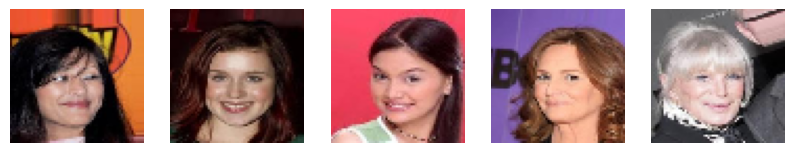

In [10]:
# display sample images
images, _ = next(train_generator)

plt.figure(figsize=(10,5))
for i in range(5):
  plt.subplot(1,5,i+1)
  plt.imshow(images[i])
  plt.axis("off")
plt.show()

In [11]:
validation_generator = datagen.flow_from_directory(
    "celeba_small",
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="input",
    subset="training"
)

Found 4000 images belonging to 1 classes.


In [12]:
#encoder
input_img=Input(shape=(64,64,3))
x= Conv2D(
    32,
    (3,3),
    activation='relu',
    padding='same'
)(input_img)
x= MaxPooling2D(
    (2,2),
    padding='same'
)(x)
x= Conv2D(
    64,
    (3,3),
    activation='relu',
    padding='same'
)(x)
encoded =MaxPooling2D(
    (2,2),
    padding='same'
)(x)

In [13]:
#Decoder
x=Conv2D(64,(3,3),activation="relu",padding="same")(encoded)
x=UpSampling2D((2,2))(x)
x=Conv2D(32,(3,3),activation='relu',padding='same')(x)
x=UpSampling2D((2,2))(x)
decoded=Conv2D(3,(3,3),activation='sigmoid',padding='same')(x)

In [14]:
#create model
autoencoder = Model(
    input_img,
    decoded
)

In [15]:
# compile model
autoencoder.compile(
    optimizer= 'adam',
    loss='binary_crossentropy'
    )

In [16]:
#model summary
autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64, 64, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 75,651 (295.51 KB)

 Trainable params: 75,651 (295.51 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# train model
history = autoencoder.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
    )

Epoch 1/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 13s 60ms/step - loss: 0.5269 - val_loss: 0.4968
Epoch 2/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 45ms/step - loss: 0.4929 - val_loss: 0.4918
Epoch 3/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.4895 - val_loss: 0.4912
Epoch 4/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 46ms/step - loss: 0.4877 - val_loss: 0.4868
Epoch 5/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 53ms/step - loss: 0.4859 - val_loss: 0.4858
Epoch 6/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.4850 - val_loss: 0.4849
Epoch 7/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 56ms/step - loss: 0.4847 - val_loss: 0.4836
Epoch 8/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 48ms/step - loss: 0.4837 - val_loss: 0.4834
Epoch 9/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 7s 54ms/step - loss: 0.4832 - val_loss: 0.4828
Epoch 10/10
125/125 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - loss: 0.4831 - val_loss: 0.4827


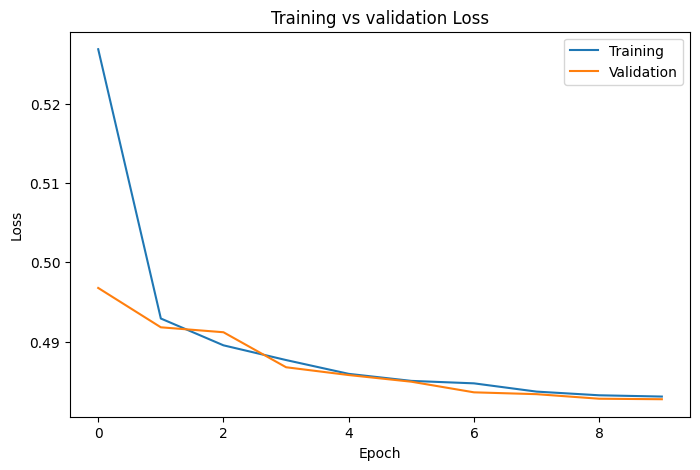

In [18]:
#plot loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs validation Loss")
plt.legend(["Training","Validation"])
plt.show()

In [19]:
#evaluate model
loss=autoencoder.evaluate(validation_generator)
print("validation loss:",loss)

125/125 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.4827
validation loss: 0.4827177822589874


In [20]:
# reconstruct images
images, _ =next(validation_generator)
reconstructed = autoencoder.predict(images)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step


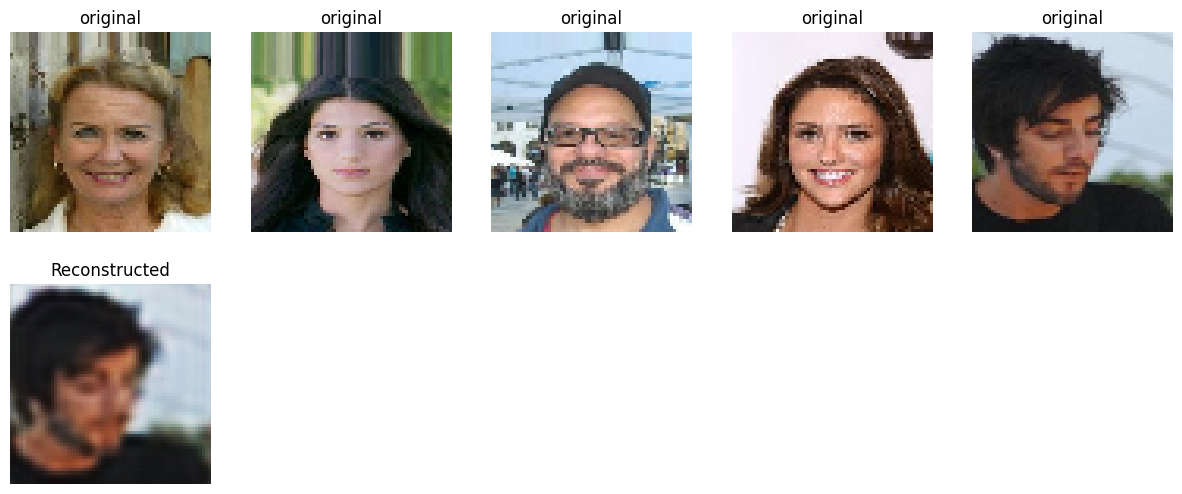

In [21]:
# display the images
n=5
plt.figure(figsize=(15,6))
for i in range(n):
  plt.subplot(2,n,i+1)
  plt.imshow(images[i])
  plt.title("original")
  plt.axis("off")
  plt.subplot(2,n,n+1)
  plt.imshow(reconstructed[i])
  plt.title("Reconstructed")
  plt.axis("off")
plt.show()